In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER sentiment lexicon
nltk.download('vader_lexicon', quiet=True)

True

In [2]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================
# Replace the string below with the path you copied from Kaggle
file_path = '/kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv' 
df = pd.read_csv(file_path)

# Drop rows where critical fields are missing
df = df.dropna(subset=['review', 'condition']).copy()
print(f"Loaded {df.shape[0]:,} reviews.")

Loaded 160,398 reviews.


In [3]:
# =============================================================================
# 2. CLINICAL TEXT PREPROCESSING
# =============================================================================
def clean_review_text(text):
    text = re.sub(r'&#039;', "'", str(text))
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

print("Cleaning review text...")
df['cleaned_review'] = df['review'].apply(clean_review_text)

Cleaning review text...


In [4]:
# =============================================================================
# 3. SENTIMENT INTENSITY SCORING (NLP)
# =============================================================================
sia = SentimentIntensityAnalyzer()
print("Calculating sentiment polarity scores...")

# Get compound score (-1.0 to +1.0)
df['sentiment_score'] = df['cleaned_review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def categorize_sentiment(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

Calculating sentiment polarity scores...


In [5]:
# =============================================================================
# 4. HEALTHCARE AGGREGATIONS & METRICS
# =============================================================================
condition_summary = df.groupby('condition').agg(
    Review_Count=('review', 'count'),
    Avg_Rating=('rating', 'mean'),
    Avg_Sentiment=('sentiment_score', 'mean'),
    Negative_Review_Pct=('sentiment_category', lambda x: (x == 'Negative').mean() * 100)
).reset_index()

# Filter for statistical significance (>= 100 reviews)
significant_conditions = condition_summary[condition_summary['Review_Count'] >= 100]
worst_experience_conditions = significant_conditions.sort_values(by='Avg_Sentiment', ascending=True).head(10)

/tmp/ipykernel_16/3019501121.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_experience_conditions, x='Avg_Sentiment', y='condition', palette='Reds_r')


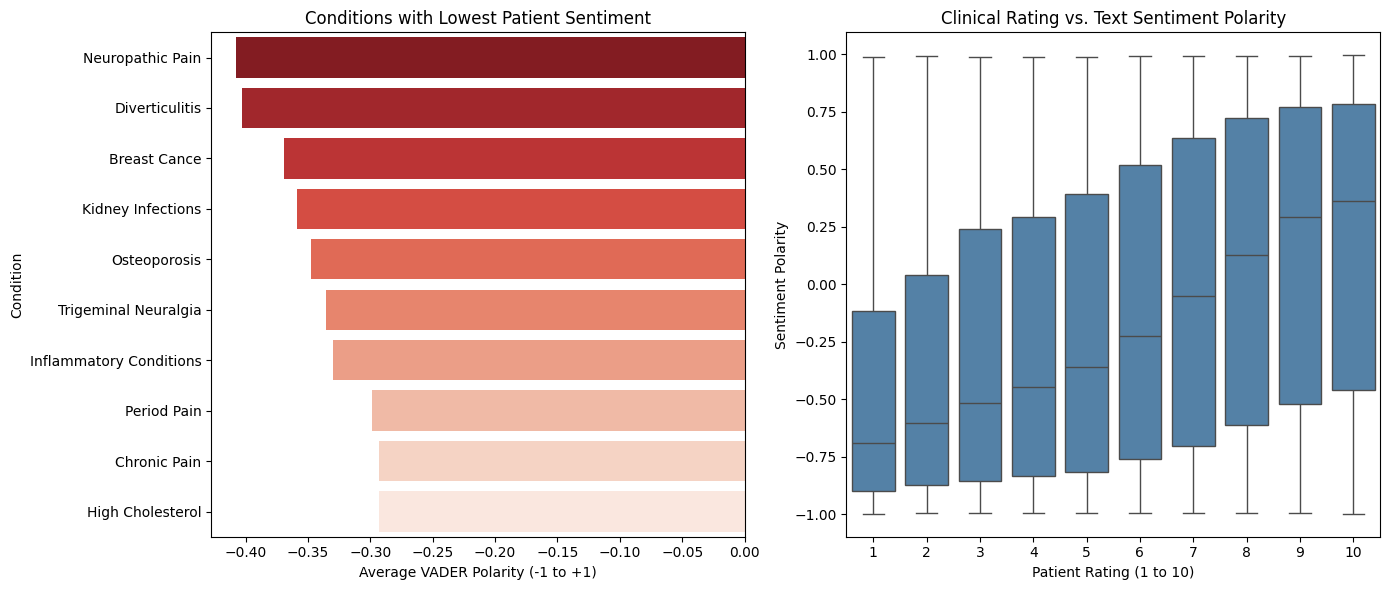

In [6]:
# =============================================================================
# 5. VISUALIZATION
# =============================================================================
plt.figure(figsize=(14, 6))

# Subplot 1: Worst Conditions
plt.subplot(1, 2, 1)
sns.barplot(data=worst_experience_conditions, x='Avg_Sentiment', y='condition', palette='Reds_r')
plt.title('Conditions with Lowest Patient Sentiment')
plt.xlabel('Average VADER Polarity (-1 to +1)')
plt.ylabel('Condition')

# Subplot 2: Rating vs Sentiment
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='rating', y='sentiment_score', color='steelblue', showfliers=False)
plt.title('Clinical Rating vs. Text Sentiment Polarity')
plt.xlabel('Patient Rating (1 to 10)')
plt.ylabel('Sentiment Polarity')

plt.tight_layout()
plt.show()